# Full Pipeline

### Parameterized pipeline for entire strategy. Assumes data has already been sourced with 00-source-data.py.

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.stattools import coint
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

from datasketch import MinHash, MinHashLSH

### Parameters

In [2]:
# --- PCA --- #
PCA_k = 10

# --- PageRank --- #
PR_CORR_THRESHOLD = 0.8
PR_NUM_ASSETS = 25
PR_BETA = 0.85

# --- Cointegration --- #
COINT_PVAL = 0.05

# --- GMM --- #
GMM_k_RANGE = [2, 3, 4]
GMM_CALM_ONLY = True
GMM_z_TRADE_THRESH = 1.0
GMM_z_EXIT_THRESH = 0.2

# --- Minhash --- #
SHINGLE_k = 3
MINHASH_NUM_PERM = 64
MINHASH_WINDOW_SIZE = 10
MINHASH_FORWARD_DAYS = 10
MINHASH_MIN_SIGNALS = 200

# --- Supervised Model --- #
USE_LR = False
USE_RFC = True

# --- Backtest --- #
SIGNAL_COLS = ['final_signal', 'model_signal']
COLORS      = {'final_signal': '#2196F3', 'model_signal': '#FF5722'}

In [3]:
run_dir = f"../data/runs/{PCA_k}_{PR_CORR_THRESHOLD}_{PR_NUM_ASSETS}_{GMM_CALM_ONLY}_{GMM_z_TRADE_THRESH}_{SHINGLE_k}_{USE_RFC}"
os.makedirs(run_dir, exist_ok=True)
print(f"Folder '{run_dir}' created or already exists.")

fig_dir = run_dir + "/figs/"
os.makedirs(fig_dir, exist_ok=True)

Folder '../data/runs/10_0.8_25_True_1.0_3_True' created or already exists.


### Load Data

In [4]:
train_returns = pd.read_csv("../data/raw/equity_returns_train.csv", index_col=0, parse_dates=True)
val_returns   = pd.read_csv("../data/raw/equity_returns_val.csv",   index_col=0, parse_dates=True)
test_returns  = pd.read_csv("../data/raw/equity_returns_test.csv",  index_col=0, parse_dates=True)

### Dimension Reduction

In [5]:
# align columns - keep only tickers present in all splits
common_cols   = train_returns.columns.intersection(val_returns.columns).intersection(test_returns.columns)
train_returns = train_returns[common_cols]
val_returns   = val_returns[common_cols]
test_returns  = test_returns[common_cols]

scaler = StandardScaler()

scaled_train = pd.DataFrame(
    scaler.fit_transform(train_returns),
    index=train_returns.index,
    columns=train_returns.columns
)
scaled_val = pd.DataFrame(
    scaler.transform(val_returns),
    index=val_returns.index,
    columns=val_returns.columns
)
scaled_test = pd.DataFrame(
    scaler.transform(test_returns),
    index=test_returns.index,
    columns=test_returns.columns
)

pca = PCA(n_components=PCA_k)
pca.fit(scaled_train)

train_reconstructed = pca.inverse_transform(pca.transform(scaled_train))
train_residuals     = pd.DataFrame(
    train_returns.values - train_reconstructed,
    index=train_returns.index,
    columns=train_returns.columns
)

val_reconstructed = pca.inverse_transform(pca.transform(scaled_val))
val_residuals     = pd.DataFrame(
    val_returns.values - val_reconstructed,
    index=val_returns.index,
    columns=val_returns.columns
)

test_reconstructed = pca.inverse_transform(pca.transform(scaled_test))
test_residuals     = pd.DataFrame(
    test_returns.values - test_reconstructed,
    index=test_returns.index,
    columns=test_returns.columns
)

train_residuals.to_csv("../data/manipulated/residuals_train.csv")
val_residuals.to_csv("../data/manipulated/residuals_val.csv")
test_residuals.to_csv("../data/manipulated/residuals_test.csv")

full_residuals = pd.concat([train_residuals, val_residuals, test_residuals])
full_residuals.to_csv("../data/manipulated/residuals_full.csv")

train_start = train_residuals.index.min()
train_end   = train_residuals.index.max()
val_start   = val_residuals.index.min()
val_end     = val_residuals.index.max()
test_start  = test_residuals.index.min()
test_end    = test_residuals.index.max()

print(f'Train: {train_start.date()} to {train_end.date()} ({len(train_residuals)} rows)')
print(f'Val:   {val_start.date()} to {val_end.date()} ({len(val_residuals)} rows)')
print(f'Test:  {test_start.date()} to {test_end.date()} ({len(test_residuals)} rows)')
print(f'Assets: {len(common_cols)}')

Train: 2016-07-06 to 2023-12-29 (1885 rows)
Val:   2024-01-02 to 2024-12-31 (252 rows)
Test:  2025-01-02 to 2025-12-31 (250 rows)
Assets: 467


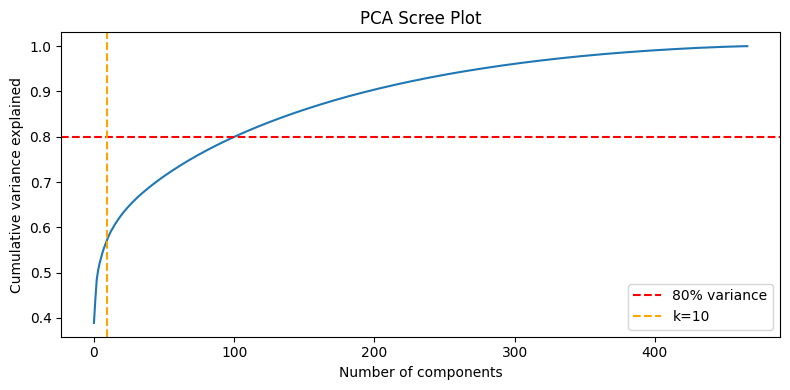

In [6]:
pca_full = PCA()
pca_full.fit(scaled_train)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.cumsum(pca_full.explained_variance_ratio_))
ax.axhline(0.8, color='red', linestyle='--', label='80% variance')
ax.axvline(PCA_k - 1, color='orange', linestyle='--', label=f'k={PCA_k}')
ax.set_xlabel('Number of components')
ax.set_ylabel('Cumulative variance explained')
ax.set_title('PCA Scree Plot')
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir + 'pca_scree.png', dpi=150)
plt.show()

### PageRank

In [7]:
train_corr = train_residuals.corr()

def pagerank(mtx, beta=PR_BETA, tol=1e-6, max_iter=100):
    A = mtx.to_numpy() if hasattr(mtx, "to_numpy") else mtx
    n = A.shape[0]
    row_sums = A.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    P = A / row_sums
    r = np.ones(n) / n
    for _ in range(max_iter):
        r_new = beta * P.T @ r + (1 - beta) / n
        if np.linalg.norm(r_new - r, 1) < tol:
            break
        r = r_new
    return r

weight_matrix = train_corr.copy()
weight_matrix[train_corr <= PR_CORR_THRESHOLD] = 0
weight_matrix = weight_matrix ** 2
weight_matrix = weight_matrix.mask(np.eye(len(weight_matrix), dtype=bool), 0)

r = pagerank(weight_matrix)
pagerank_df = pd.DataFrame({
    "Asset": weight_matrix.index,
    "PageRank": r
}).sort_values("PageRank", ascending=False)

top_assets = pagerank_df.head(PR_NUM_ASSETS)
print(top_assets)

    Asset  PageRank
80    CDW  0.004191
116  CTSH  0.004134
24   AMCR  0.004045
202   HAS  0.003974
307   NKE  0.003873
36    APH  0.003856
390   STZ  0.003842
147    EL  0.003834
258   LIN  0.003823
457    WY  0.003816
198  GRMN  0.003816
211   HPQ  0.003799
37    APO  0.003798
62    BLK  0.003787
142   ECL  0.003752
329  PAYX  0.003705
76   CBRE  0.003699
108   CRH  0.003694
40   ARES  0.003692
246   KKR  0.003679
113   CSX  0.003644
5     ACN  0.003611
296   MSI  0.003609
231    IT  0.003596
402   TEL  0.003558


/tmp/ipykernel_12024/3740759503.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="PageRank", y="Asset", data=top_assets, palette="viridis", ax=ax)


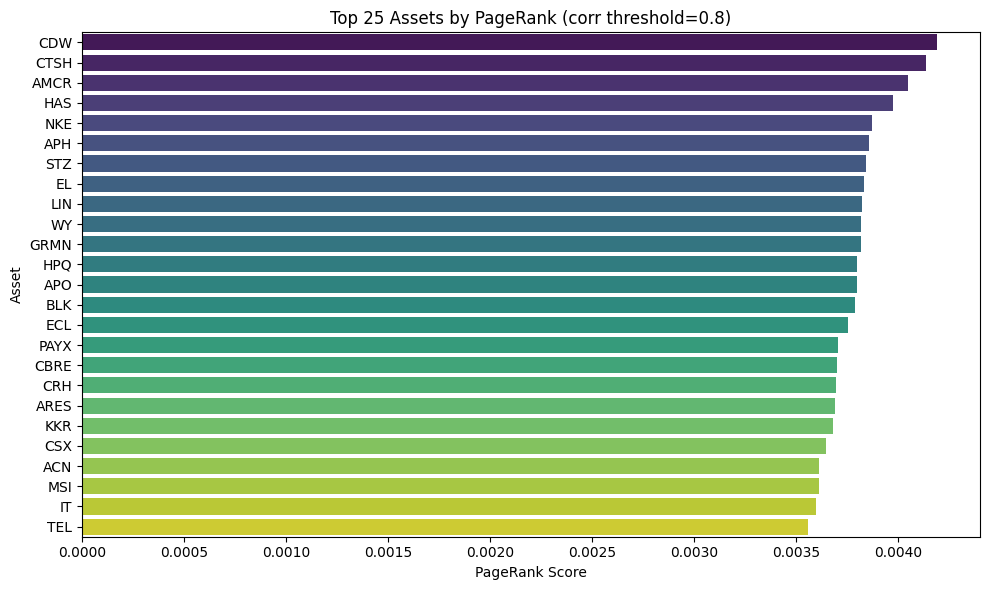

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x="PageRank", y="Asset", data=top_assets, palette="viridis", ax=ax)
ax.set_title(f'Top {PR_NUM_ASSETS} Assets by PageRank (corr threshold={PR_CORR_THRESHOLD})')
ax.set_xlabel('PageRank Score')
ax.set_ylabel('Asset')
plt.tight_layout()
plt.savefig(fig_dir + 'pagerank_top_assets.png', dpi=150)
plt.show()

filtered_residuals = full_residuals[top_assets["Asset"]]
filtered_residuals.to_csv("../data/manipulated/pr_filtered_residuals.csv", index=True)
filtered_train_residuals = filtered_residuals.loc[train_start:train_end]

### Cointegration

In [9]:
assets = filtered_train_residuals.columns

def find_cointegrated_pairs(residuals_df, candidates, pvalue_threshold=COINT_PVAL):
    pairs = []
    tickers = list(candidates)
    for i in range(len(tickers)):
        for j in range(i+1, len(tickers)):
            a, b = tickers[i], tickers[j]
            _, pvalue, _ = coint(residuals_df[a], residuals_df[b])
            if pvalue < pvalue_threshold:
                model = LinearRegression().fit(residuals_df[[b]], residuals_df[a])
                beta = model.coef_[0]
                pairs.append((a, b, pvalue, beta))
    pairs_df = pd.DataFrame(pairs, columns=["asset_a", "asset_b", "pvalue", "beta"])
    return pairs_df.sort_values("pvalue")

cointegrated_pairs = find_cointegrated_pairs(filtered_train_residuals, assets, pvalue_threshold=COINT_PVAL)
cointegrated_pairs.to_csv("../data/manipulated/cointegrated_pairs.csv", index=False)
print(f'{len(cointegrated_pairs)} cointegrated pairs found')
cointegrated_pairs.head()

300 cointegrated pairs found


,asset_a,asset_b,pvalue,beta
2,CDW,HAS,0.0,1.245941
7,CDW,LIN,0.0,0.943356
42,CTSH,CSX,0.0,0.874385
43,CTSH,ACN,0.0,0.832903
44,CTSH,MSI,0.0,0.977100


### GMM Regimes

In [10]:
def select_best_k(spread, k_range=GMM_k_RANGE):
    X = spread.values.reshape(-1, 1)
    bic_scores = []
    for k in k_range:
        gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=42, n_init=5)
        gmm.fit(X)
        bic_scores.append((k, gmm.bic(X)))
    return min(bic_scores, key=lambda x: x[1])[0]

def fit_gmm(spread, n_components):
    X = spread.values.reshape(-1, 1)
    gmm = GaussianMixture(n_components=n_components, covariance_type="full", random_state=42, n_init=5)
    gmm.fit(X)
    return gmm

os.makedirs("../data/manipulated/spreads", exist_ok=True)

for _, row in cointegrated_pairs.iterrows():
    a, b, beta = row['asset_a'], row['asset_b'], row['beta']

    train_spread = filtered_train_residuals[a] - beta * filtered_train_residuals[b]
    full_spread  = filtered_residuals[a] - beta * filtered_residuals[b]

    best_k = select_best_k(train_spread)
    gmm    = fit_gmm(train_spread, best_k)
    labels = gmm.predict(full_spread.values.reshape(-1, 1))

    sorted_idx    = np.argsort(gmm.means_.flatten())
    remap         = {old: new for new, old in enumerate(sorted_idx)}
    sorted_labels = np.array([remap[l] for l in labels])

    train_mean = train_spread.mean()
    train_std  = train_spread.std()
    z_scores   = (full_spread - train_mean) / train_std

    sorted_stds = np.sqrt(gmm.covariances_.flatten())[sorted_idx]
    calm_regime = int(np.argmin(sorted_stds))

    signal = pd.Series(0, index=full_spread.index)
    if GMM_CALM_ONLY:
        signal[(z_scores < -GMM_z_TRADE_THRESH) & (sorted_labels == calm_regime)] =  1
        signal[(z_scores >  GMM_z_TRADE_THRESH) & (sorted_labels == calm_regime)] = -1
    else:
        signal[z_scores < -GMM_z_TRADE_THRESH] =  1
        signal[z_scores >  GMM_z_TRADE_THRESH] = -1
    signal[z_scores.abs() < GMM_z_EXIT_THRESH] = 0

    df = pd.DataFrame({
        'spread':  full_spread.values,
        'regime':  sorted_labels,
        'z_score': z_scores.values,
        'gmm_signal':  signal.values,
    }, index=full_spread.index)

    df.to_csv(f'../data/manipulated/spreads/{a}_{b}.csv')

print(f'Saved {len(cointegrated_pairs)} spread files')

Saved 300 spread files


### MinHash

In [11]:
MIN_SIGNALS = MINHASH_MIN_SIGNALS

def discretise(spread_window):
    mean = spread_window.mean()
    std  = spread_window.std()
    z    = (spread_window - mean) / std
    
    symbols = []
    for val in z:
        if val < -1.0:       symbols.append('L')
        elif val < -0.2:     symbols.append('l')
        elif val <  0.2:     symbols.append('0')
        elif val <  1.0:     symbols.append('h')
        else:                symbols.append('H')
    return symbols

def shingle(symbols, k=SHINGLE_k):
    return set(''.join(symbols[i:i+k]) for i in range(len(symbols) - k + 1))

def make_minhash(shingles, num_perm=MINHASH_NUM_PERM):
    m = MinHash(num_perm=num_perm)
    for s in shingles:
        m.update(s.encode('utf-8'))
    return m

def build_lsh_index(spread, window_size=MINHASH_WINDOW_SIZE, num_perm=MINHASH_NUM_PERM):
    lsh = MinHashLSH(threshold=0.5, num_perm=num_perm)
    signatures = {}
    for i in range(len(spread) - window_size):
        window = spread.iloc[i:i + window_size]
        m = make_minhash(shingle(discretise(window)))
        key = f"w_{i}"
        lsh.insert(key, m)
        signatures[key] = (m, i)
    return lsh, signatures

def compute_minhash_signals(spread, gmm_signals, lsh, signatures,
                             window_size=MINHASH_WINDOW_SIZE, forward_days=MINHASH_FORWARD_DAYS):
    minhash_signals = pd.Series(0.0, index=spread.index)
    signal_days = gmm_signals[gmm_signals != 0].index
    for date in signal_days:
        i = spread.index.get_loc(date)
        if i < window_size:
            continue
        window = spread.iloc[i - window_size:i]
        query_m = make_minhash(shingle(discretise(window)))
        similar_keys = lsh.query(query_m)
        if not similar_keys:
            continue
        forward_returns = []
        for key in similar_keys:
            _, start_idx = signatures[key]
            end_idx = start_idx + window_size + forward_days
            if end_idx < len(spread) and start_idx + window_size <= i:
                fwd = spread.iloc[start_idx + window_size + forward_days] - spread.iloc[start_idx + window_size]
                forward_returns.append(fwd)
        if forward_returns:
            minhash_signals.loc[date] = np.mean(forward_returns)
    return minhash_signals

def combine_signals(gmm_signal, minhash_signal):
    if gmm_signal == 0:
        return 0
    if gmm_signal == 1 and minhash_signal > 0:
        return 1
    if gmm_signal == -1 and minhash_signal < 0:
        return -1
    return 0

# filter to active pairs (enough GMM signals)
active_pairs_list = []
for _, row in cointegrated_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    df = pd.read_csv(f'../data/manipulated/spreads/{a}_{b}.csv', index_col=0, parse_dates=True, date_format='%Y-%m-%d')
    n_signals = (df['gmm_signal'] != 0).sum()
    if n_signals >= MIN_SIGNALS:
        active_pairs_list.append(row)
        print(f"{a}/{b} - {n_signals} signals, keeping")
    else:
        print(f"{a}/{b} - {n_signals} signals, dropping")

active_pairs = pd.DataFrame(active_pairs_list)
active_pairs.to_csv("../data/manipulated/active_pairs.csv")
print(f"\n{len(active_pairs)} pairs kept from {len(cointegrated_pairs)}")

CDW/HAS - 216 signals, keeping
CDW/LIN - 137 signals, dropping
CTSH/CSX - 185 signals, dropping
CTSH/ACN - 147 signals, dropping
CTSH/MSI - 161 signals, dropping
CTSH/IT - 251 signals, keeping
HAS/EL - 157 signals, dropping
BLK/PAYX - 67 signals, dropping
AMCR/ACN - 144 signals, dropping
AMCR/MSI - 193 signals, dropping
AMCR/ARES - 260 signals, keeping
AMCR/BLK - 0 signals, dropping
AMCR/APO - 302 signals, keeping
AMCR/EL - 156 signals, dropping
AMCR/STZ - 94 signals, dropping
AMCR/APH - 158 signals, dropping
AMCR/IT - 204 signals, keeping
HAS/STZ - 127 signals, dropping
HAS/CRH - 285 signals, keeping
HAS/CBRE - 233 signals, keeping
HAS/KKR - 161 signals, dropping
NKE/HPQ - 137 signals, dropping
HAS/TEL - 72 signals, dropping
HAS/IT - 211 signals, keeping
NKE/APO - 0 signals, dropping
ECL/ACN - 167 signals, dropping
CBRE/CRH - 173 signals, dropping
ECL/MSI - 153 signals, dropping
BLK/IT - 347 signals, keeping
BLK/ACN - 179 signals, dropping
BLK/CSX - 0 signals, dropping
BLK/ARES - 282 

In [12]:
for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    path = f'../data/manipulated/spreads/{a}_{b}.csv'
    df = pd.read_csv(path, index_col=0, parse_dates=True)

    full_spread  = df['spread']
    train_spread = full_spread.loc[train_start:train_end]
    lsh, signatures = build_lsh_index(train_spread)

    minhash_signals = compute_minhash_signals(full_spread, df['gmm_signal'], lsh, signatures)

    df['minhash_signal'] = minhash_signals
    df['final_signal']   = df.apply(
        lambda r: combine_signals(r['gmm_signal'], r['minhash_signal']), axis=1
    )
    df.to_csv(path)
    print(f"done: {a}/{b}")

done: CDW/HAS
done: CTSH/IT
done: AMCR/ARES
done: AMCR/APO
done: AMCR/IT
done: HAS/CRH
done: HAS/CBRE
done: HAS/IT
done: BLK/IT
done: BLK/ARES
done: NKE/EL
done: STZ/ECL
done: APH/APO
done: NKE/IT
done: APO/MSI
done: APH/EL
done: GRMN/ACN
done: GRMN/IT
done: EL/APO
done: STZ/IT
done: APH/CRH
done: WY/HPQ
done: ACN/MSI
done: KKR/TEL
done: CTSH/STZ
done: CTSH/AMCR
done: CBRE/IT
done: CBRE/TEL
done: EL/TEL
done: EL/CSX
done: WY/ARES
done: HAS/APO
done: HAS/CSX
done: WY/CSX
done: GRMN/MSI
done: EL/ARES
done: CDW/CSX
done: CDW/CTSH
done: EL/GRMN
done: APH/CSX
done: CTSH/ARES
done: STZ/BLK
done: CDW/AMCR
done: CDW/WY
done: CTSH/CRH
done: LIN/CSX
done: CTSH/KKR
done: CDW/EL
done: CDW/CBRE
done: CDW/KKR
done: ECL/KKR
done: APH/WY
done: CDW/STZ
done: STZ/ARES
done: APH/KKR
done: AMCR/KKR
done: STZ/CBRE
done: STZ/CRH
done: STZ/KKR
done: AMCR/CBRE
done: GRMN/BLK
done: LIN/KKR
done: AMCR/HAS
done: AMCR/CRH
done: NKE/STZ
done: GRMN/KKR
done: PAYX/CRH
done: PAYX/KKR
done: MSI/TEL
done: CTSH/PAYX
don

### Supervised Model

In [13]:
FEATURES = ["spread", "z_score", "regime"]
TARGET   = "final_signal"

train_frames, val_frames, test_frames = [], [], []

for _, row in active_pairs.iterrows():
    path = f'../data/manipulated/spreads/{row["asset_a"]}_{row["asset_b"]}.csv'
    df   = pd.read_csv(path, index_col=0, parse_dates=True)
    df   = df[FEATURES + [TARGET]].dropna()
    train_frames.append(df.loc[train_start:train_end])
    val_frames.append(df.loc[val_start:val_end])
    test_frames.append(df.loc[test_start:test_end])

train_df = pd.concat(train_frames)
val_df   = pd.concat(val_frames)
test_df  = pd.concat(test_frames)

print(f'Train rows: {len(train_df):,}  | Val rows: {len(val_df):,} | Test rows: {len(test_df):,}')
print('Train class distribution:')
print(train_df[TARGET].value_counts().sort_index())

X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values
X_val   = val_df[FEATURES].values
y_val   = val_df[TARGET].values
X_test  = test_df[FEATURES].values
y_test  = test_df[TARGET].values

feat_scaler = StandardScaler()
X_train = feat_scaler.fit_transform(X_train)
X_val   = feat_scaler.transform(X_val)
X_test  = feat_scaler.transform(X_test)

Train rows: 214,890  | Val rows: 28,728 | Test rows: 28,500
Train class distribution:
final_signal
-1      8162
 0    197039
 1      9689
Name: count, dtype: int64


=== Random Forest - Train ===
              precision    recall  f1-score   support

  Short (-1)       0.43      1.00      0.60      8162
    Exit (0)       1.00      0.90      0.94    197039
    Long (1)       0.49      1.00      0.66      9689

    accuracy                           0.90    214890
   macro avg       0.64      0.96      0.74    214890
weighted avg       0.96      0.90      0.92    214890

=== Random Forest - Val ===
              precision    recall  f1-score   support

  Short (-1)       0.28      1.00      0.44       675
    Exit (0)       1.00      0.87      0.93     27337
    Long (1)       0.29      1.00      0.45       716

    accuracy                           0.88     28728
   macro avg       0.52      0.96      0.61     28728
weighted avg       0.97      0.88      0.91     28728



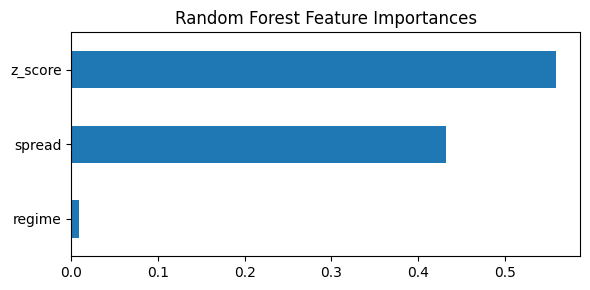

In [14]:
if USE_LR:
    model = LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    print('=== Logistic Regression - Train ===')
    print(classification_report(y_train, model.predict(X_train), target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))
    print('=== Logistic Regression - Val ===')
    print(classification_report(y_val, model.predict(X_val), target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))

if USE_RFC:
    model = RandomForestClassifier(n_estimators=100, class_weight='balanced', max_depth=8, random_state=42)
    model.fit(X_train, y_train)
    print('=== Random Forest - Train ===')
    print(classification_report(y_train, model.predict(X_train), target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))
    print('=== Random Forest - Val ===')
    print(classification_report(y_val, model.predict(X_val), target_names=['Short (-1)', 'Exit (0)', 'Long (1)']))

    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    fig, ax = plt.subplots(figsize=(6, 3))
    importances.plot(kind='barh', ax=ax)
    ax.set_title('Random Forest Feature Importances')
    plt.tight_layout()
    plt.savefig(fig_dir + 'rf_feature_importances.png', dpi=150)
    plt.show()

In [15]:
# write model_signal back to each spread CSV
for _, row in active_pairs.iterrows():
    a, b = row["asset_a"], row["asset_b"]
    path = f"../data/manipulated/spreads/{a}_{b}.csv"
    df   = pd.read_csv(path, index_col=0, parse_dates=True)
    valid = df[FEATURES].dropna()
    X = feat_scaler.transform(valid.values)
    df.loc[valid.index, "model_signal"] = model.predict(X)
    df.to_csv(path)

print(f"model_signal written to {len(active_pairs)} spread files")

model_signal written to 114 spread files


### Backtest

In [59]:
def compute_pair_pnl(signal: pd.Series, spread: pd.Series) -> pd.Series:
    """
    Daily spread change PnL.
      signal +1  => long spread  => earn spread_t - spread_{t-1}
      signal -1  => short spread => earn -(spread_t - spread_{t-1})
    1-bar lag: signal seen at close of t, position taken at t+1.
    """
    spread_z = (spread - train_mean) / train_std 
    spread_ret = spread_z.diff()
    
    # stateful position: hold until exit signal
    position = pd.Series(0.0, index=signal.index)
    current_pos = 0
    for i, (date, sig) in enumerate(signal.items()):
        if current_pos == 0 and sig != 0:
            current_pos = sig      # enter
        elif current_pos != 0 and sig == 0:
            current_pos = 0        # exit (z crossed back)
        position.iloc[i] = current_pos
    
    return (position.shift(1).fillna(0) * spread_ret)

def backtest_metrics(log_ret: pd.Series, periods_per_year=252) -> dict:
    total   = log_ret.sum()
    ann_ret = log_ret.mean() * periods_per_year
    vol     = log_ret.std() * np.sqrt(periods_per_year)
    sharpe  = ann_ret / vol if vol > 0 else np.nan
    cum     = log_ret.cumsum()
    max_dd  = (cum - cum.cummax()).min()
    nonzero = log_ret[log_ret != 0]
    hit_rate = (nonzero > 0).mean() if len(nonzero) else np.nan
    return {
        'Total log return': round(total, 4),
        'Ann. log return':  round(ann_ret, 4),
        'Ann. volatility':  round(vol, 4),
        'Sharpe ratio':     round(sharpe, 3),
        'Max drawdown':     round(max_dd, 4),
        'Hit rate':         round(hit_rate, 3),
        'Active days':      int((log_ret != 0).sum()),
    }

def run_backtest(period_start, period_end, label):
    pair_pnl = {col: [] for col in SIGNAL_COLS}
    for _, row in active_pairs.iterrows():
        a, b = row['asset_a'], row['asset_b']
        path = f'../data/manipulated/spreads/{a}_{b}.csv'
        try:
            df = pd.read_csv(path, index_col=0, parse_dates=True)
        except FileNotFoundError:
            continue
        missing = [c for c in SIGNAL_COLS if c not in df.columns]
        if missing:
            continue
        period_df = df.loc[period_start:period_end].dropna(subset=SIGNAL_COLS + ['spread'])
        if len(period_df) < 10:
            continue
        for col in SIGNAL_COLS:
            pnl = compute_pair_pnl(period_df[col], period_df['spread'])
            pair_pnl[col].append(pnl.rename(f'{a}_{b}'))

    portfolio = {}
    for col in SIGNAL_COLS:
        all_series     = pd.concat(pair_pnl[col], axis=1).fillna(0)
        portfolio[col] = all_series.sum(axis=1) / all_series.shape[1]

    portfolio_df = pd.DataFrame(portfolio)
    cumulative   = portfolio_df.cumsum()

    print(f'\n=== {label} - Portfolio daily log-return stats ===')
    print(portfolio_df.describe().round(6))

    metrics = pd.DataFrame(
        {col: backtest_metrics(portfolio_df[col]) for col in SIGNAL_COLS}
    )
    print(f'\n=== {label} - Metrics ===')
    print(metrics)

    # cumulative PnL
    fig, ax = plt.subplots(figsize=(12, 5))
    for col in SIGNAL_COLS:
        cumulative[col].plot(ax=ax, label=col, color=COLORS[col], linewidth=1.5)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Cumulative Log Return - {label} (Equal-Weighted, Asset A)')
    ax.set_ylabel('Cumulative Log Return')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.savefig(fig_dir + f'cumulative_pnl_{label.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

    # drawdown
    fig, ax = plt.subplots(figsize=(12, 4))
    for col in SIGNAL_COLS:
        cum = cumulative[col]
        dd  = cum - cum.cummax()
        dd.plot(ax=ax, label=col, color=COLORS[col], linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Drawdown - {label}')
    ax.set_ylabel('Drawdown (log return)')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.savefig(fig_dir + f'drawdown_{label.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

    # per-pair bar chart (val only, for manageable size)
    final_totals = {s.name: s.sum() for s in pair_pnl['final_signal']}
    lr_totals    = {s.name: s.sum() for s in pair_pnl['model_signal']}
    pairs_sorted = sorted(final_totals.keys())
    x = np.arange(len(pairs_sorted))
    width = 0.35
    fig, ax = plt.subplots(figsize=(max(12, len(pairs_sorted) * 0.4), 5))
    ax.bar(x - width/2, [final_totals[p] for p in pairs_sorted], width, label='final_signal', color=COLORS['final_signal'], alpha=0.8)
    ax.bar(x + width/2, [lr_totals.get(p, 0) for p in pairs_sorted],    width, label='model_signal',    color=COLORS['model_signal'],    alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(pairs_sorted, rotation=90, fontsize=7)
    ax.set_title(f'Per-Pair Total Log Return - {label}')
    ax.set_ylabel('Total Log Return')
    ax.legend()
    plt.tight_layout()
    plt.savefig(fig_dir + f'per_pair_pnl_{label.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

    # rolling sharpe (30-day)
    fig, ax = plt.subplots(figsize=(12, 4))
    for col in SIGNAL_COLS:
        roll = portfolio_df[col].rolling(30)
        rolling_sharpe = (roll.mean() / roll.std()) * np.sqrt(252)
        rolling_sharpe.plot(ax=ax, label=col, color=COLORS[col], linewidth=1.2)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Rolling 30-Day Sharpe - {label}')
    ax.set_ylabel('Sharpe')
    ax.set_xlabel('Date')
    ax.legend()
    plt.tight_layout()
    plt.savefig(fig_dir + f'rolling_sharpe_{label.lower().replace(" ", "_")}.png', dpi=150)
    plt.show()

    return portfolio_df, metrics, pair_pnl


=== Train - Portfolio daily log-return stats ===
       final_signal  model_signal
count   1885.000000   1885.000000
mean       0.061593      0.119442
std        0.065938      0.128803
min       -0.179767     -0.293738
25%        0.008896      0.014062
50%        0.046178      0.082816
75%        0.097583      0.192495
max        0.729968      0.894988

=== Train - Metrics ===
                  final_signal  model_signal
Total log return      116.1019      225.1478
Ann. log return        15.5213       30.0993
Ann. volatility         1.0467        2.0447
Sharpe ratio           14.8280       14.7210
Max drawdown           -0.1798       -0.2937
Hit rate                0.9440        0.9340
Active days          1638.0000     1676.0000


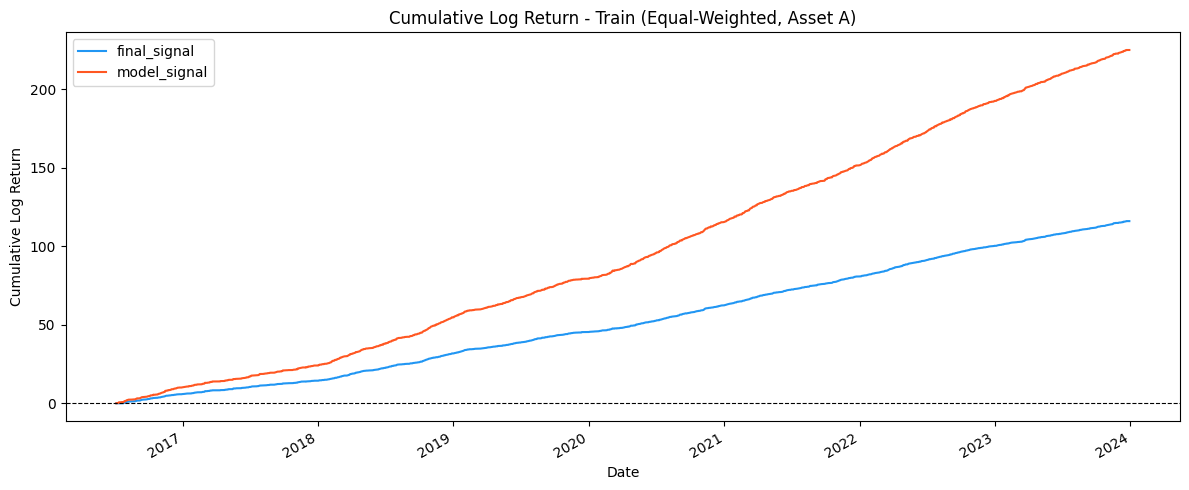

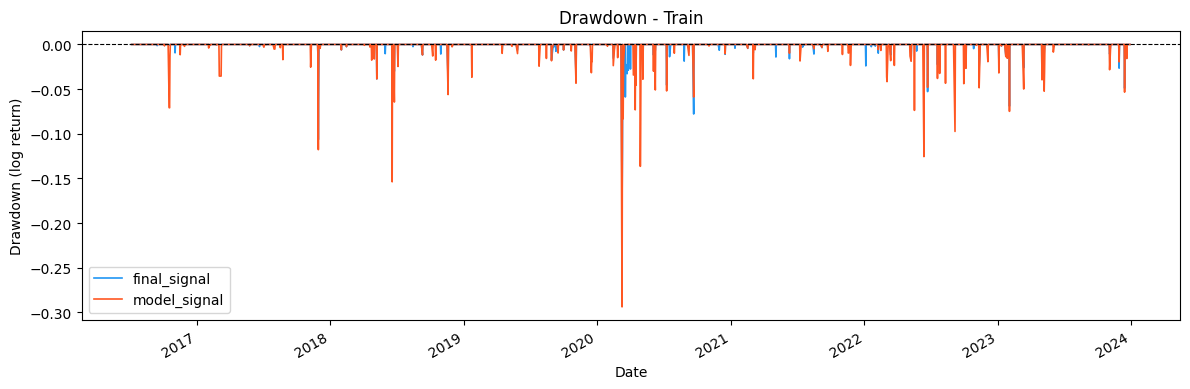

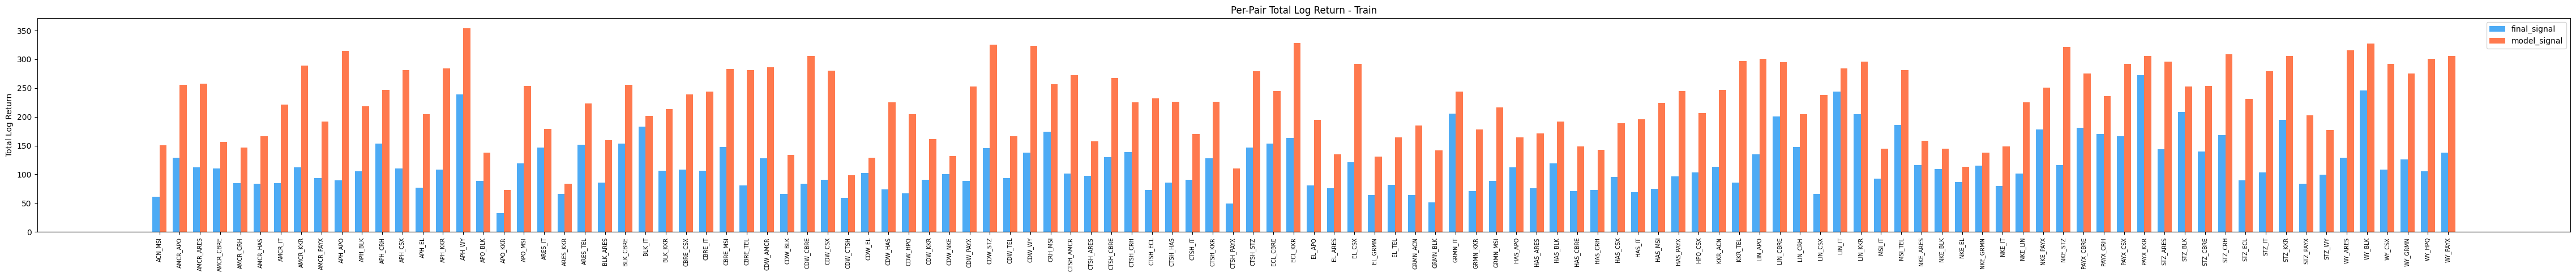

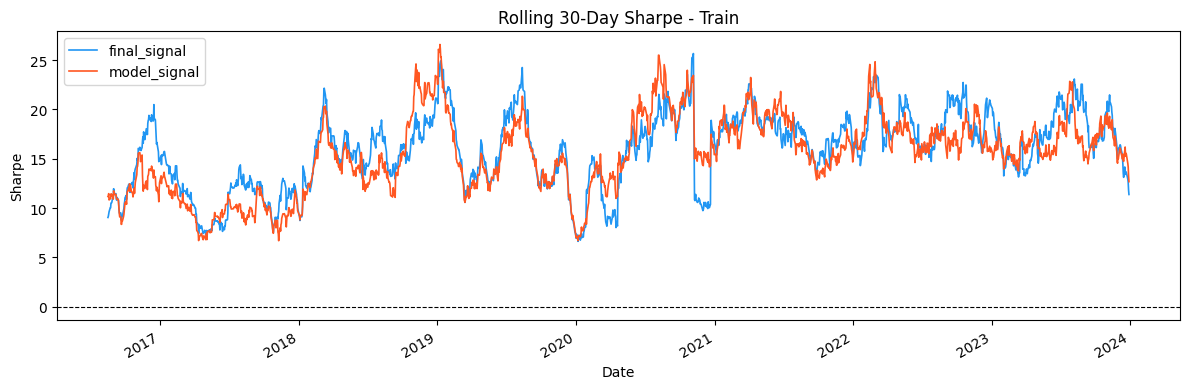

In [60]:
train_portfolio, train_metrics, train_pair_pnl = run_backtest(train_start, train_end, "Train")


=== Validation - Portfolio daily log-return stats ===
       final_signal  model_signal
count    252.000000    252.000000
mean       0.040155      0.126177
std        0.041213      0.135586
min       -0.023394     -0.104428
25%        0.006580      0.016243
50%        0.026802      0.079293
75%        0.060514      0.204965
max        0.216476      0.651148

=== Validation - Metrics ===
                  final_signal  model_signal
Total log return       10.1191       31.7967
Ann. log return        10.1191       31.7967
Ann. volatility         0.6542        2.1524
Sharpe ratio           15.4670       14.7730
Max drawdown           -0.0234       -0.1044
Hit rate                0.9680        0.9310
Active days           218.0000      231.0000


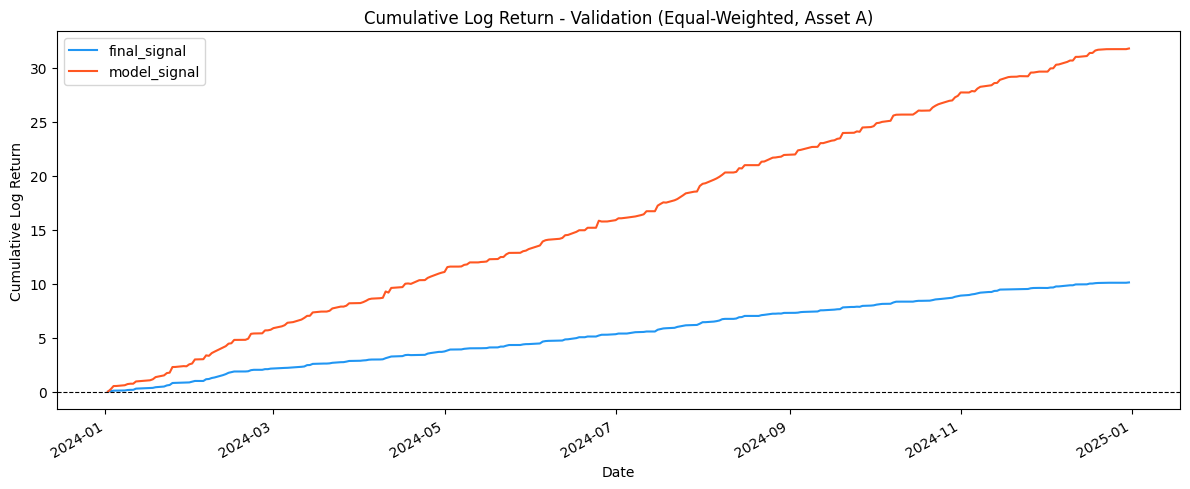

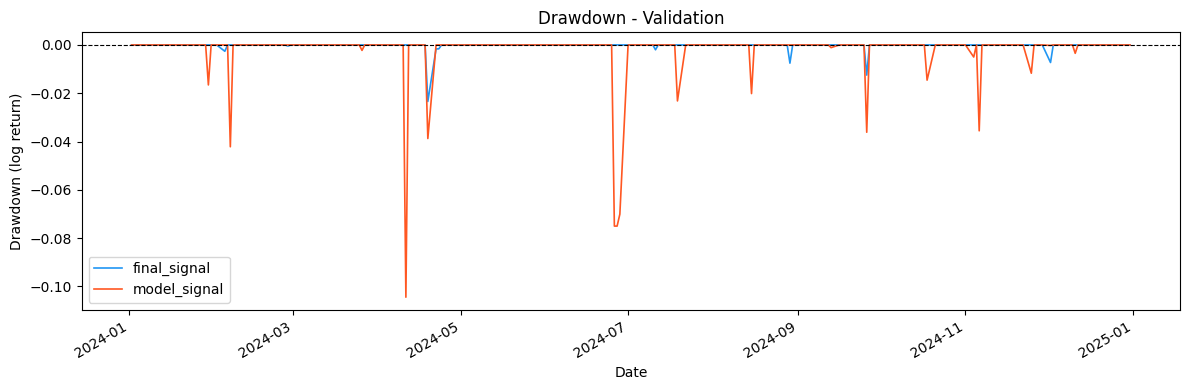

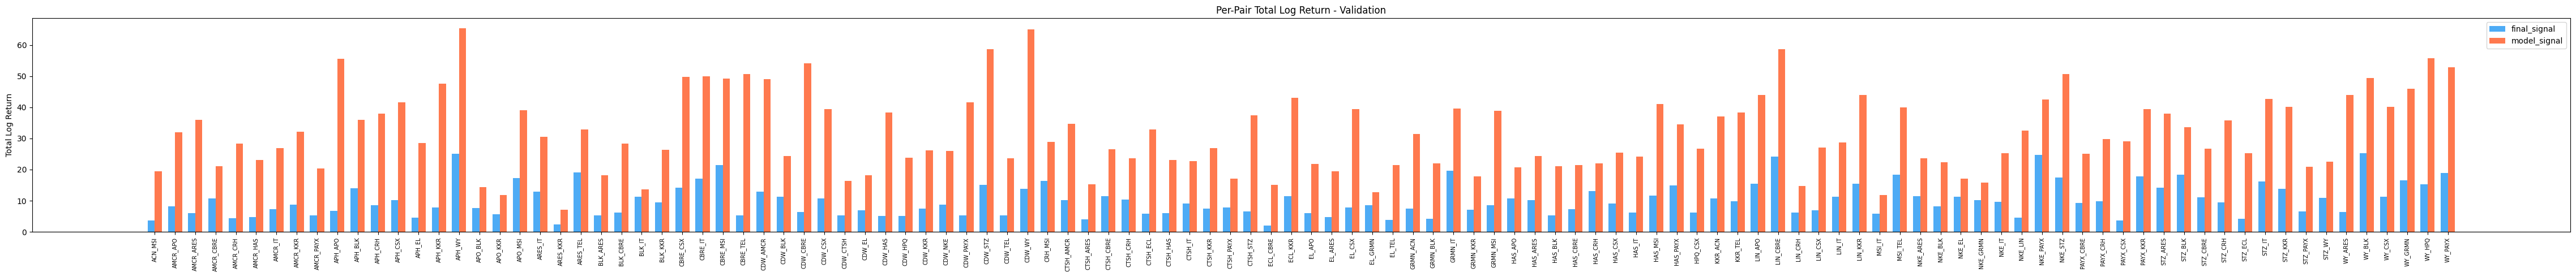

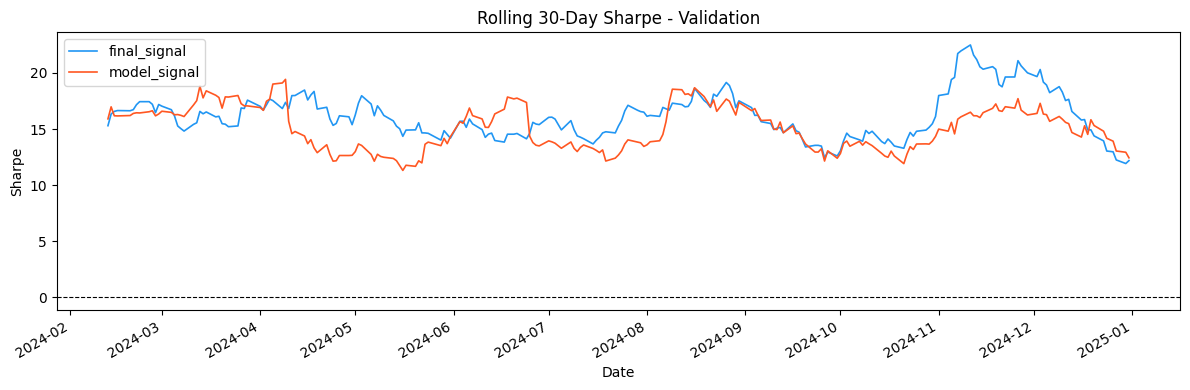

In [61]:
val_portfolio, val_metrics, val_pair_pnl = run_backtest(val_start, val_end, "Validation")


=== Test - Portfolio daily log-return stats ===
       final_signal  model_signal
count    250.000000    250.000000
mean       0.044389      0.128285
std        0.049546      0.140559
min       -0.072218     -0.229840
25%        0.008086      0.017981
50%        0.031207      0.096450
75%        0.063016      0.205280
max        0.454891      0.897902

=== Test - Metrics ===
                  final_signal  model_signal
Total log return       11.0972       32.0712
Ann. log return        11.1860       32.3278
Ann. volatility         0.7865        2.2313
Sharpe ratio           14.2220       14.4880
Max drawdown           -0.0722       -0.2298
Hit rate                0.9590        0.9350
Active days           222.0000      231.0000


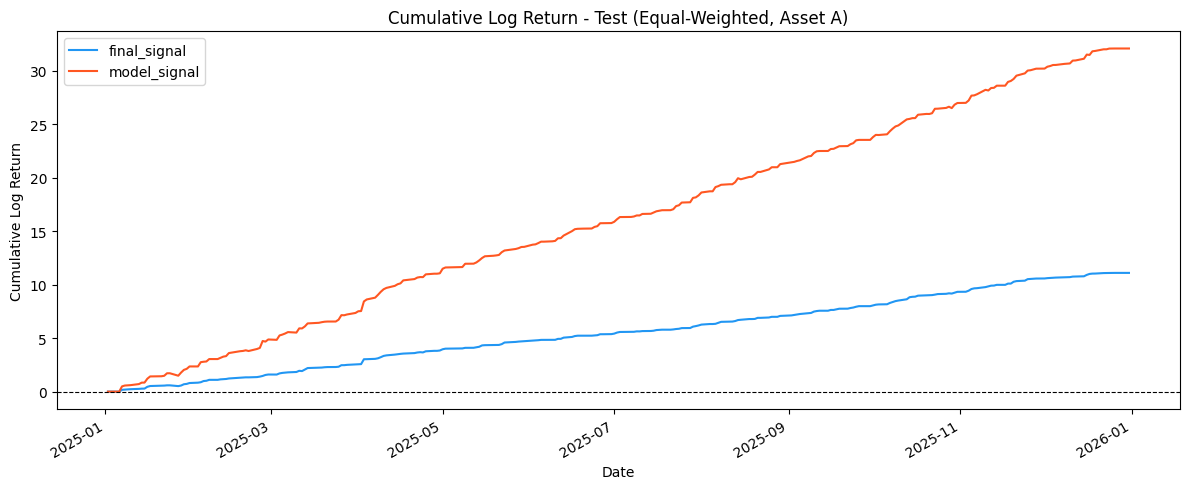

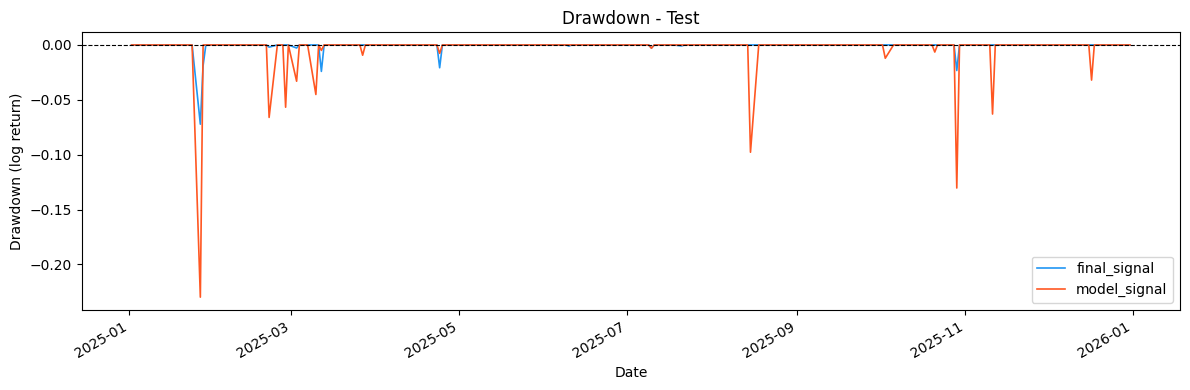

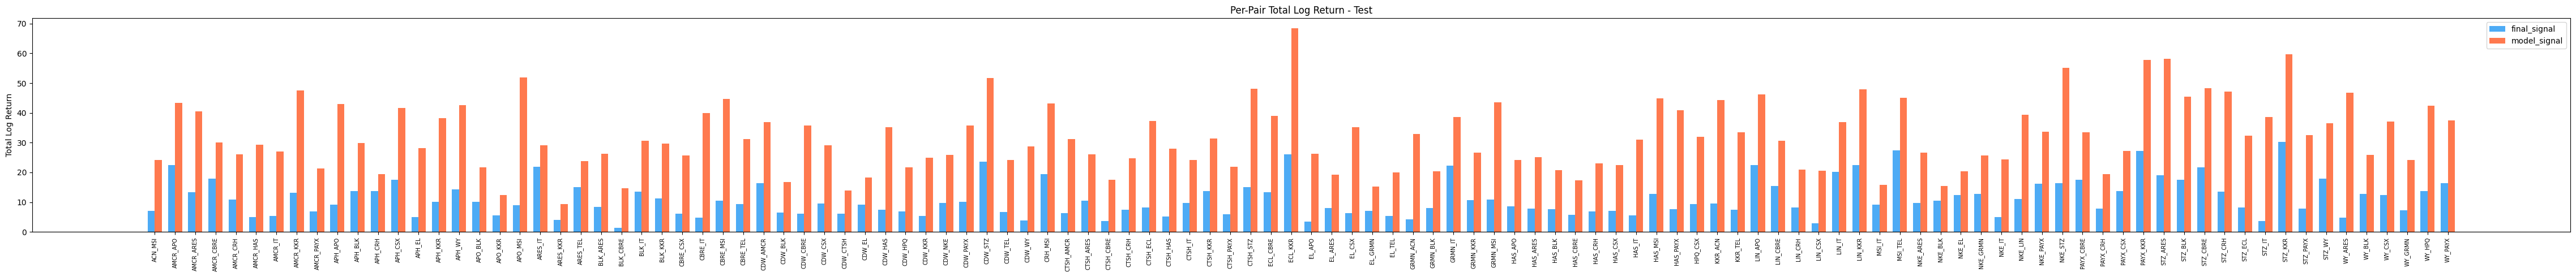

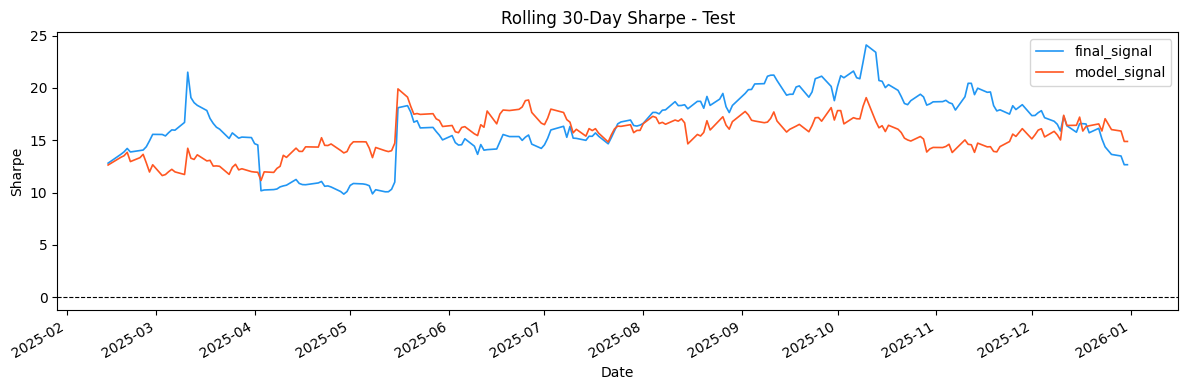

In [62]:
test_portfolio, test_metrics, test_pair_pnl = run_backtest(test_start, test_end, "Test")

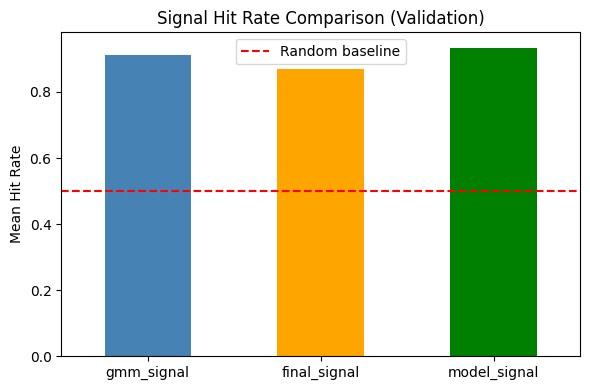

gmm_signal      0.913
final_signal    0.869
model_signal    0.934
dtype: float64


In [63]:
hitrate_results = {"gmm_signal": [], "final_signal": [], "model_signal": []}

for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    df = pd.read_csv(f'../data/manipulated/spreads/{a}_{b}.csv', index_col=0, parse_dates=True)

    val_df = df.loc[val_start:val_end].copy()

    # spread returns (use diff, not log)
    spread_ret = val_df['spread'].diff()

    for col in hitrate_results.keys():
        pos = val_df[col].shift(1)

        mask = pos != 0
        if mask.sum() == 0:
            continue

        pnl = pos[mask] * spread_ret[mask]

        hitrate = (pnl > 0).mean()
        hitrate_results[col].append(hitrate)

# -----------------------
# Convert to dataframe
# -----------------------
hitrate_df = pd.DataFrame({
    k: pd.Series(v) for k, v in hitrate_results.items()
})

summary = hitrate_df.mean()

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(6,4))
summary.plot(kind='bar', color=['steelblue', 'orange', 'green'])
plt.axhline(0.5, linestyle='--', color='red', label='Random baseline')
plt.ylabel('Mean Hit Rate')
plt.title('Signal Hit Rate Comparison (Validation)')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir + 'signal_hitrate_val.png', dpi=150)
plt.show()

print(summary.round(3))

### Intermediate Signal Agreement Analysis

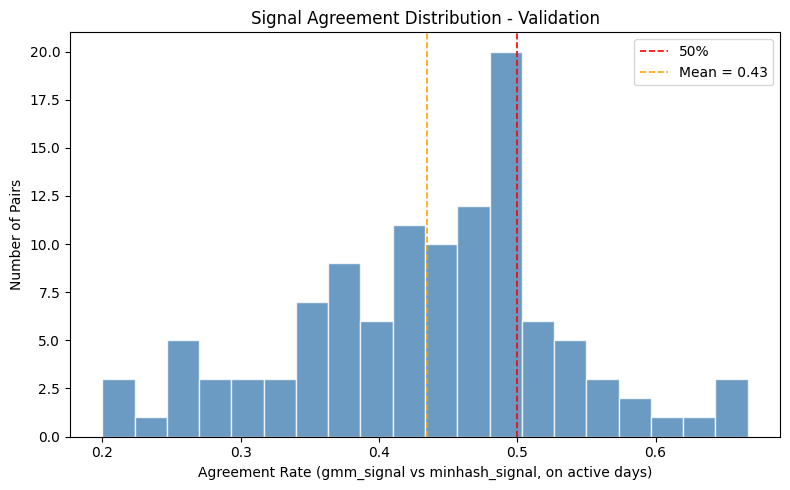

       agreement  n_signals
count    114.000    114.000
mean       0.434     27.939
std        0.098      8.561
min        0.200      8.000
25%        0.369     23.000
50%        0.444     26.000
75%        0.500     31.000
max        0.667     56.000


In [64]:
# How often do final_signal and model_signal agree on val set?
agreement_stats = []

for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    path = f'../data/manipulated/spreads/{a}_{b}.csv'
    try:
        df = pd.read_csv(path, index_col=0, parse_dates=True)
    except FileNotFoundError:
        continue

    val_df_pair = df.loc[val_start:val_end]
    active_mask = ~(
    (val_df_pair['gmm_signal'] == 0) &
    (val_df_pair['minhash_signal'] == 0)
    )
    
    if active_mask.sum() == 0:
        continue

    active = val_df_pair[active_mask]
    agreement = (np.sign(active['gmm_signal']) == np.sign(active['minhash_signal'])).mean()
    agreement_stats.append({'pair': f'{a}_{b}', 'agreement': agreement, 'n_signals': active_mask.sum()})

agreement_df = pd.DataFrame(agreement_stats).sort_values('agreement')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(agreement_df['agreement'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='50%')
ax.axvline(agreement_df['agreement'].mean(), color='orange', linestyle='--', linewidth=1.2,
           label=f'Mean = {agreement_df["agreement"].mean():.2f}')
ax.set_xlabel('Agreement Rate (gmm_signal vs minhash_signal, on active days)')
ax.set_ylabel('Number of Pairs')
ax.set_title('Signal Agreement Distribution - Validation')
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir + 'signal_agreement_val.png', dpi=150)
plt.show()

print(agreement_df.describe().round(3))

### Final Signal Agreement Analysis

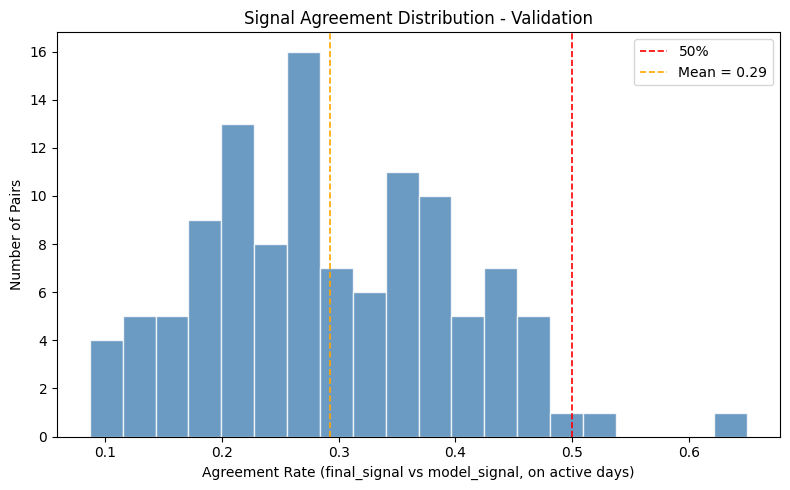

       agreement  n_signals
count    114.000    114.000
mean       0.293     42.772
std        0.107     10.619
min        0.087     19.000
25%        0.209     36.000
50%        0.278     44.000
75%        0.371     50.000
max        0.650     66.000


In [65]:
# How often do final_signal and model_signal agree on val set?
agreement_stats = []

for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    path = f'../data/manipulated/spreads/{a}_{b}.csv'
    try:
        df = pd.read_csv(path, index_col=0, parse_dates=True)
    except FileNotFoundError:
        continue
    if 'model_signal' not in df.columns:
        continue

    val_df_pair = df.loc[val_start:val_end]
    active_mask = ~(
    (val_df_pair['final_signal'] == 0) &
    (val_df_pair['model_signal'] == 0)
    )
    if active_mask.sum() == 0:
        continue

    active = val_df_pair[active_mask]
    agreement = (active['final_signal'] == active['model_signal']).mean()
    agreement_stats.append({'pair': f'{a}_{b}', 'agreement': agreement, 'n_signals': active_mask.sum()})

agreement_df = pd.DataFrame(agreement_stats).sort_values('agreement')

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(agreement_df['agreement'], bins=20, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='50%')
ax.axvline(agreement_df['agreement'].mean(), color='orange', linestyle='--', linewidth=1.2,
           label=f'Mean = {agreement_df["agreement"].mean():.2f}')
ax.set_xlabel('Agreement Rate (final_signal vs model_signal, on active days)')
ax.set_ylabel('Number of Pairs')
ax.set_title('Signal Agreement Distribution - Validation')
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir + 'signal_agreement_val.png', dpi=150)
plt.show()

print(agreement_df.describe().round(3))

In [66]:
print(agreement_df.shape)
print(agreement_df['agreement'].describe())
print(agreement_df['agreement'].value_counts().head(10))

(114, 3)
count    114.000000
mean       0.293036
std        0.106834
min        0.086957
25%        0.208882
50%        0.278424
75%        0.370963
max        0.650000
Name: agreement, dtype: float64
agreement
0.195122    2
0.208333    2
0.220000    2
0.229167    2
0.230769    2
0.250000    2
0.277778    2
0.279070    2
0.309091    2
0.333333    2
Name: count, dtype: int64


### Save Metrics

In [67]:
train_metrics.to_csv(run_dir + '/train_metrics.csv')
val_metrics.to_csv(run_dir + '/val_metrics.csv')
print('Train metrics:')
print(train_metrics)
print('\nVal metrics:')
print(val_metrics)

Train metrics:
                  final_signal  model_signal
Total log return      116.1019      225.1478
Ann. log return        15.5213       30.0993
Ann. volatility         1.0467        2.0447
Sharpe ratio           14.8280       14.7210
Max drawdown           -0.1798       -0.2937
Hit rate                0.9440        0.9340
Active days          1638.0000     1676.0000

Val metrics:
                  final_signal  model_signal
Total log return       10.1191       31.7967
Ann. log return        10.1191       31.7967
Ann. volatility         0.6542        2.1524
Sharpe ratio           15.4670       14.7730
Max drawdown           -0.0234       -0.1044
Hit rate                0.9680        0.9310
Active days           218.0000      231.0000


### Additional Backtest - Profitable Pairs Only

In [68]:
# filter to pairs profitable on final_signal in training
profitable_pairs_list = []
for _, row in active_pairs.iterrows():
    a, b = row['asset_a'], row['asset_b']
    matches = [s for s in train_pair_pnl['final_signal'] if s.name == f'{a}_{b}']
    if matches and matches[0].sum() > 0:
        profitable_pairs_list.append(row)

profitable_pairs_df = pd.DataFrame(profitable_pairs_list).reset_index(drop=True)
print(f'{len(profitable_pairs_df)} / {len(active_pairs)} pairs profitable in training:')
print(f'Percent of pairs profitable: {100*len(profitable_pairs_df)/len(active_pairs)}\n')
print(profitable_pairs_df[['asset_a', 'asset_b']].to_string(index=False))

114 / 114 pairs profitable in training:
Percent of pairs profitable: 100.0

asset_a asset_b
    CDW     HAS
   CTSH      IT
   AMCR    ARES
   AMCR     APO
   AMCR      IT
    HAS     CRH
    HAS    CBRE
    HAS      IT
    BLK      IT
    BLK    ARES
    NKE      EL
    STZ     ECL
    APH     APO
    NKE      IT
    APO     MSI
    APH      EL
   GRMN     ACN
   GRMN      IT
     EL     APO
    STZ      IT
    APH     CRH
     WY     HPQ
    ACN     MSI
    KKR     TEL
   CTSH     STZ
   CTSH    AMCR
   CBRE      IT
   CBRE     TEL
     EL     TEL
     EL     CSX
     WY    ARES
    HAS     APO
    HAS     CSX
     WY     CSX
   GRMN     MSI
     EL    ARES
    CDW     CSX
    CDW    CTSH
     EL    GRMN
    APH     CSX
   CTSH    ARES
    STZ     BLK
    CDW    AMCR
    CDW      WY
   CTSH     CRH
    LIN     CSX
   CTSH     KKR
    CDW      EL
    CDW    CBRE
    CDW     KKR
    ECL     KKR
    APH      WY
    CDW     STZ
    STZ    ARES
    APH     KKR
   AMCR     KKR
    STZ    C


=== Profitable Pairs - Validation - Portfolio daily log-return stats ===
       final_signal  model_signal
count    252.000000    252.000000
mean       0.040155      0.126177
std        0.041213      0.135586
min       -0.023394     -0.104428
25%        0.006580      0.016243
50%        0.026802      0.079293
75%        0.060514      0.204965
max        0.216476      0.651148

=== Profitable Pairs - Validation - Metrics ===
                  final_signal  model_signal
Total log return       10.1191       31.7967
Ann. log return        10.1191       31.7967
Ann. volatility         0.6542        2.1524
Sharpe ratio           15.4670       14.7730
Max drawdown           -0.0234       -0.1044
Hit rate                0.9680        0.9310
Active days           218.0000      231.0000


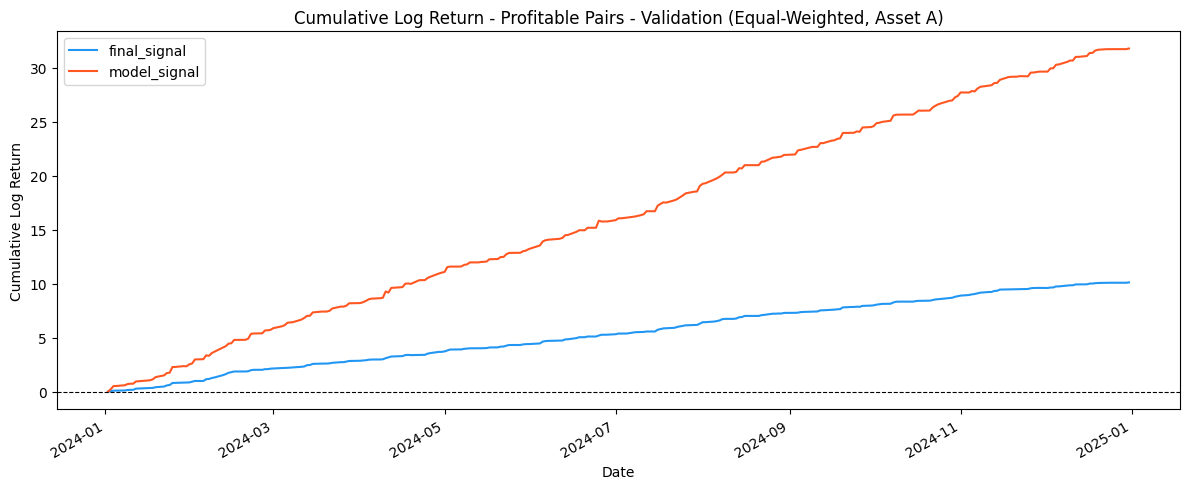

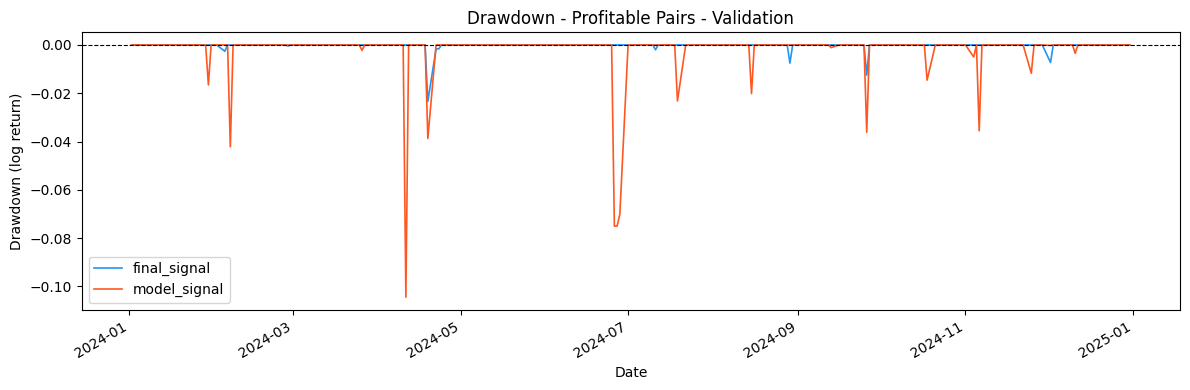

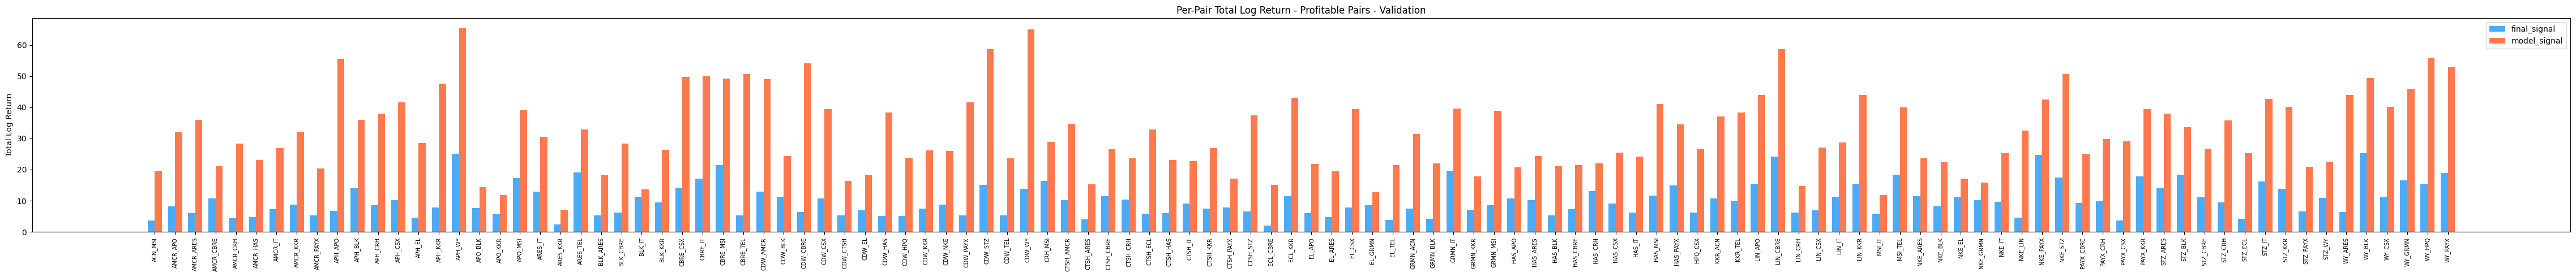

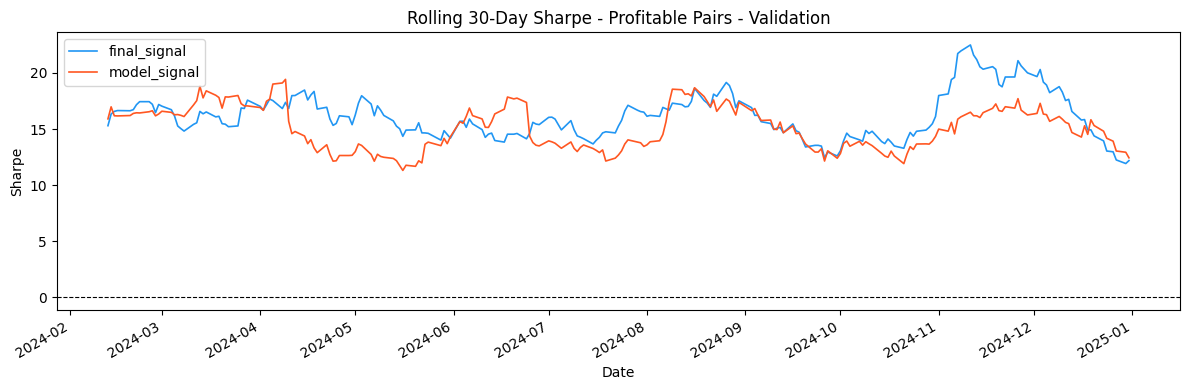

In [69]:
_orig_active = active_pairs
active_pairs = profitable_pairs_df

_, profitable_val_metrics, _ = run_backtest(val_start, val_end, 'Profitable Pairs - Validation')

active_pairs = _orig_active

profitable_val_metrics.to_csv(run_dir + '/val_metrics_profitable_pairs.csv')